In [6]:
#tools to use
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from lab_utils_multi import load_house_data
from lab_utils_common import dlc
np.set_printoptions(precision=2)
plt.style.use('./deeplearning.mplstyle')


In [8]:
#Scikit-learn has a gradient descent regression model `sklearn.linear_model.SGDRegressor` which
# best performs with normalized inputs
# `sklearn.preprocessing.StandardScaler` will perform zscore normalization
#load data set
X_train, y_train = load_house_data()
X_features = ['size(sqft)', 'bedrooms', 'floors', 'age']

In [12]:
#scale/normalize the training data set
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_train)
print(f'Peak to Peak range by column in Raw         X:{np.ptp(X_train, axis=0)}')
print(f'Peak to Peak range by clumn in Normalized   X:{np.ptp(X_norm, axis=0)}')


Peak to Peak range by column in Raw         X:[2.41e+03 4.00e+00 1.00e+00 9.50e+01]
Peak to Peak range by clumn in Normalized   X:[5.85 6.14 2.06 3.69]


In [13]:
#create and fit the regression model
sgdr = SGDRegressor(max_iter=1000)
sgdr.fit(X_norm, y_train)
print(sgdr)
print(f'number of iterations completed: {sgdr.n_iter_}, number of weight updates: {sgdr.t_}')

SGDRegressor()
number of iterations completed: 141, number of weight updates: 13960.0


In [15]:
#view parameters
b_norm = sgdr.intercept_
w_norm = sgdr.coef_
print(f'model parameters:                   w: {w_norm}, b{b_norm}')
print(f'model parameters from previous lab: w:[110.56 -21.27 -32.71 -37.97], b: 363.16')


model parameters:                   w: [110.33 -21.12 -32.55 -38.  ], b[363.17]
model parameters from previous lab: w:[110.56 -21.27 -32.71 -37.97], b: 363.16


In [17]:
#make predictions for targets of the training data
#make  a prediction using `sgdr.predict()`
y_pred_sgd = sgdr.predict(X_norm)

#make a prediction using `w`, `b`
y_pred = np.dot(X_norm, w_norm) + b_norm
print(f'prediction using np.dot() and sgdr.predit match: {(y_pred == y_pred_sgd).all()}')
print()

print(f'prediction on training set: \n{y_pred[:4]}')
print(f'Target values: \n{y_train[:4]}')


prediction using np.dot() and sgdr.predit match: True

prediction on training set: 
[295.19 485.98 389.62 492.14]
Target values: 
[300.  509.8 394.  540. ]


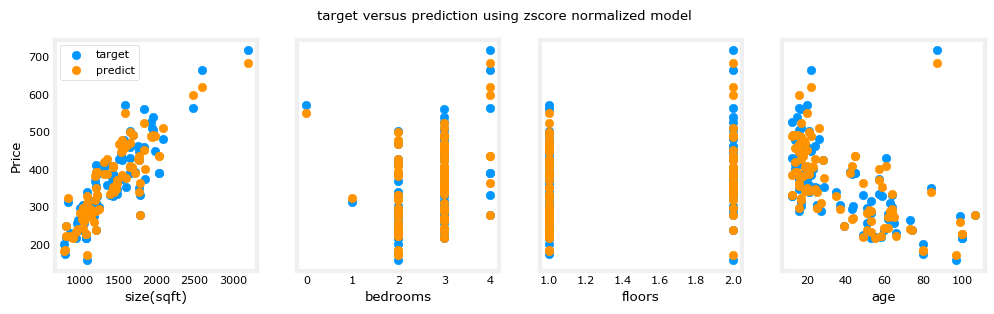

In [19]:
#plot results
#plot predictions and targets vs original features
fig, ax=plt.subplots(1,4, figsize=(12,3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:,i], y_train, label = 'target')
    ax[i].set_xlabel(X_features[i])
    ax[i].scatter(X_train[:,i], y_pred, color=dlc['dlorange'], label = 'predict')
ax[0].set_ylabel('Price'); ax[0].legend()
fig.suptitle('target versus prediction using zscore normalized model')
plt.show()